In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

In [49]:
import warnings
warnings.filterwarnings('ignore')

In [50]:
path = "https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguins.csv"
df=pd.read_csv(path, keep_default_na=False)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male
1,Adelie,Torgersen,39.5,17.4,186,3800,female
2,Adelie,Torgersen,40.3,18.0,195,3250,female
3,Adelie,Torgersen,36.7,19.3,193,3450,female
4,Adelie,Torgersen,39.3,20.6,190,3650,male
...,...,...,...,...,...,...,...
328,Chinstrap,Dream,55.8,19.8,207,4000,male
329,Chinstrap,Dream,43.5,18.1,202,3400,female
330,Chinstrap,Dream,49.6,18.2,193,3775,male
331,Chinstrap,Dream,50.8,19.0,210,4100,male


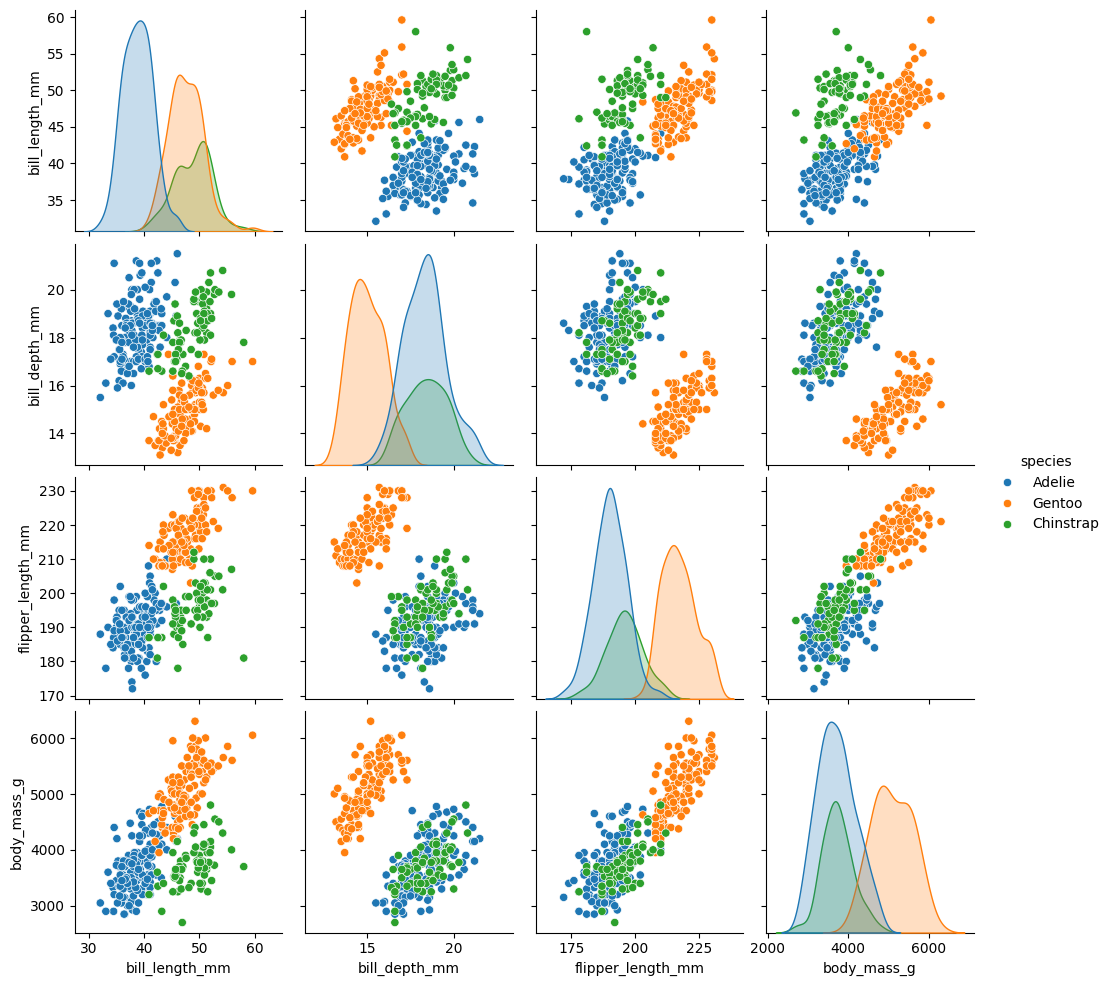

In [51]:
sns.pairplot(df,hue="species")

In [52]:
df['island_2'] = df["island"].map({'Torgersen':1, 'Dream':2,'Biscoe':0})
df["sex"]=df["sex"].map({"male":1,"female":0})
df.rename(columns={"sex": "male"}, inplace=True)
df_pair_plot=df[["species","island_2","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","male"]].copy()

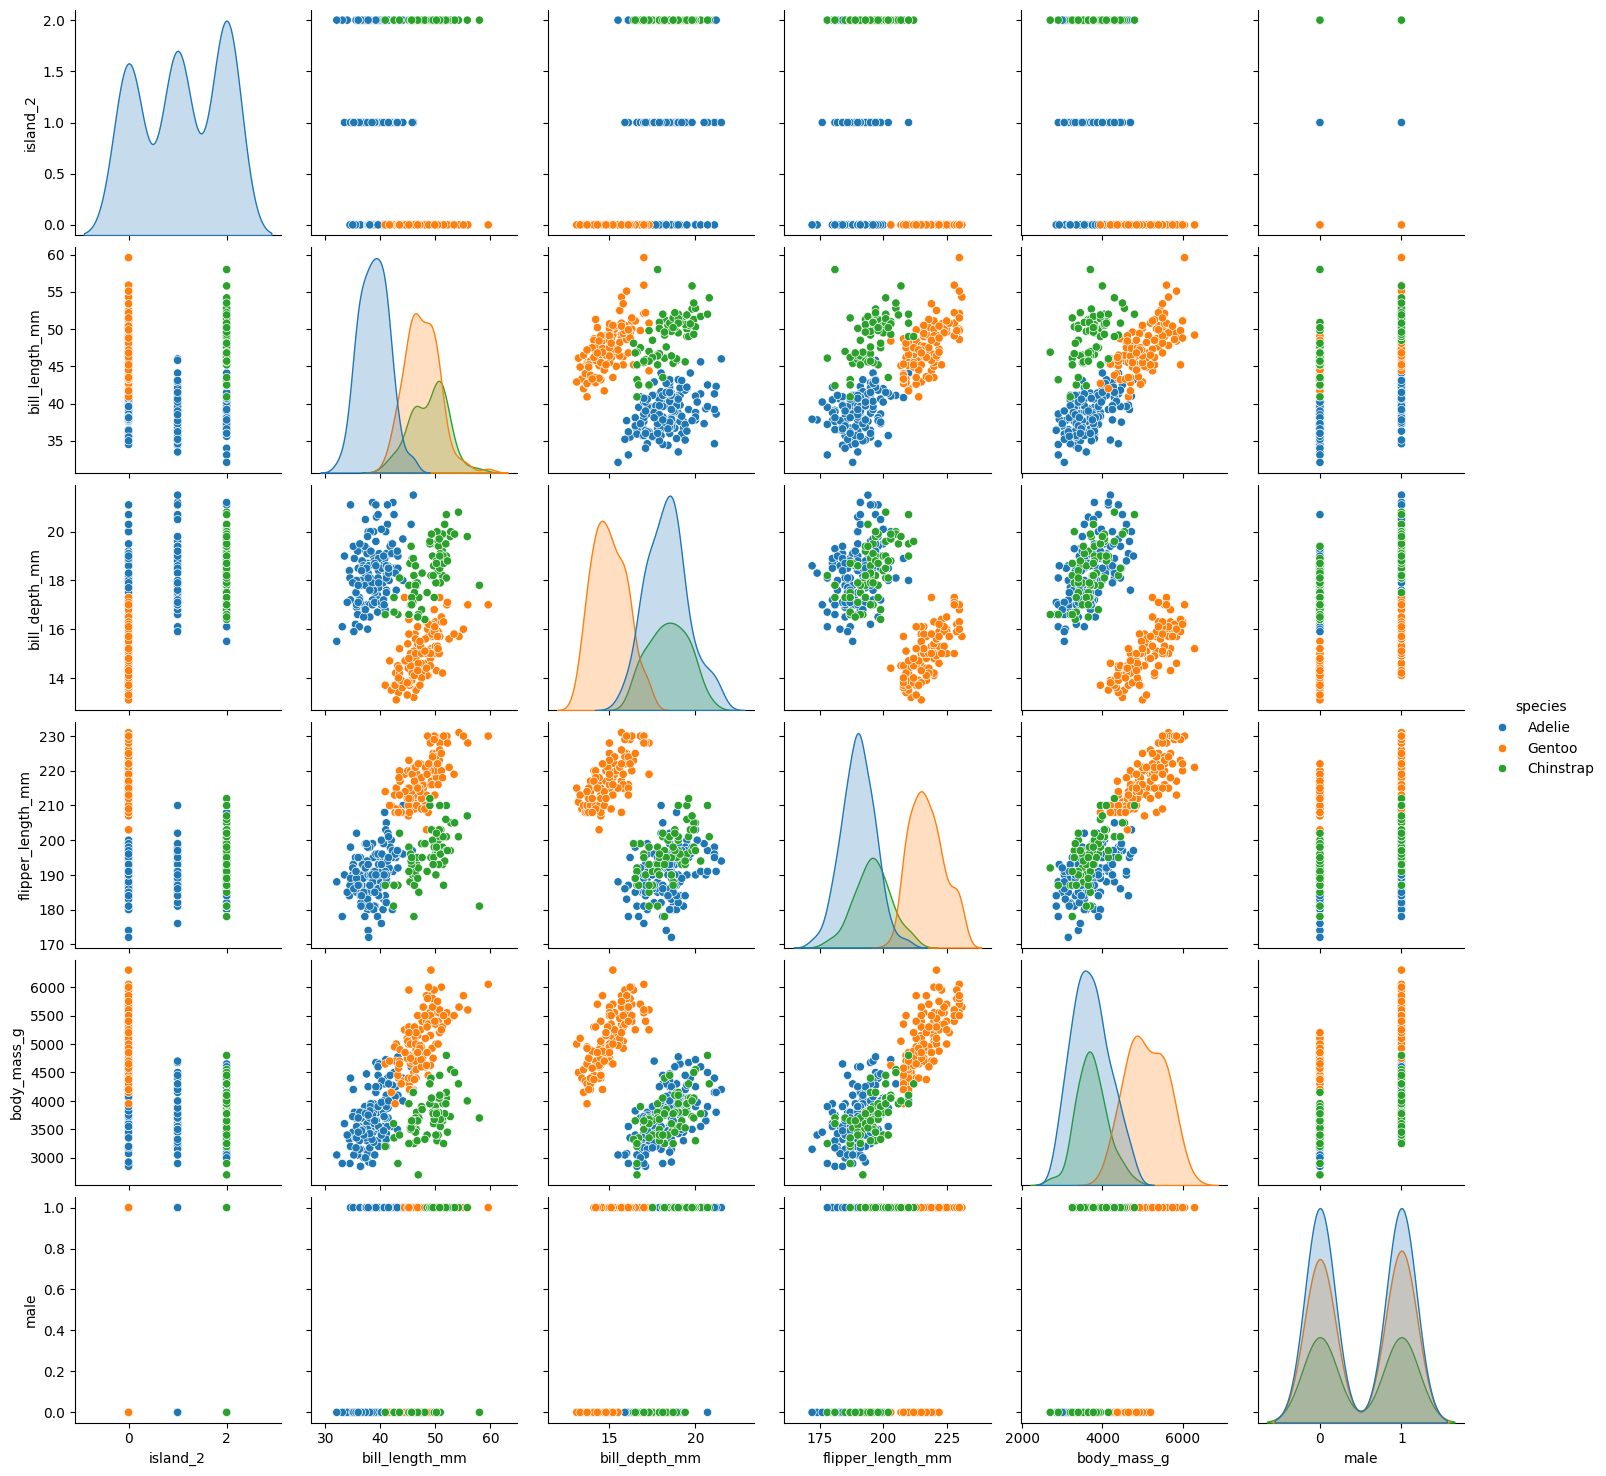

In [53]:
sns.pairplot(df_pair_plot,hue="species")

In [55]:
pd.get_dummies(df, columns=["island"],drop_first=False, dtype=int)
target = "species"
X = df.drop([target],axis=1)
y = df[target]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=667,
                                                    )